In [1]:
import serial
import numpy as np
import time
from matplotlib import pyplot as plt
from ribbn_scripts.hardware_api.hardware import Exciter,Tag

In [ ]:
com_port1="/dev/tty.usbmodem113301"
tag1=Tag(com_port1)
tag1.connect_wifi("192.168.1.24", 3333)
print(tag1.get_mac())

com_port2="/dev/tty.usbmodem113401"
tag2=Tag(com_port2)
tag2.connect_wifi("192.168.1.20", 3333)
print(tag2.get_mac())


# com_port3="/dev/tty.usbserial-1120"
# tag3=Tag(com_port3)
# print(tag3.get_mac())



b'net:up, ip:192.168.1.20, port:3333, rssi:-74\n'


## ADC noise floor plotting.
Tag1

b'ch: 1, ok\r\n' 	 b'ch: 1, ok\r\n'
Voltage array len: 3302


Text(0, 0.5, 'ADC out (mV)')

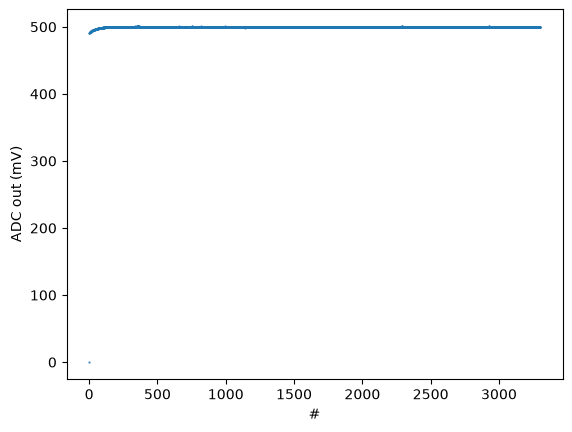

In [3]:
tag1.reflect(1)
tag1.begin_reading()
time.sleep(.2)
voltage_readings_newtag1=tag1.stop_reading()
print("Voltage array len:",len(voltage_readings_newtag1), )
plt.plot(voltage_readings_newtag1, '.',markersize=1)
plt.xlabel("#")
plt.ylabel("ADC out (mV)")

In [5]:
tag1.reflect_wifi(3)
tag1.begin_reading_wifi()
time.sleep(0.2)
voltage_readings_newtag1_wifi=tag1.stop_reading_wifi()
print("Voltage array len:",len(voltage_readings_newtag1_wifi))
plt.plot(voltage_readings_newtag1_wifi, '.', markersize=1)
plt.xlabel("#")
plt.ylabel("ADC out (mV)")

KeyboardInterrupt: 

b'ch: 3, ok\r\n' 	 b'ch: 3, ok\r\n'
Voltage array len: 3296


Text(0, 0.5, 'ADC out (mV)')

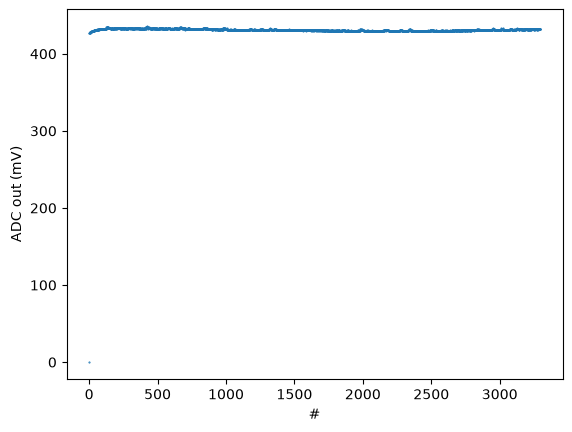

In [6]:
tag2.reflect(3)
tag2.begin_reading()
time.sleep(0.2)
voltage_readings_newtag2=tag2.stop_reading()
print("Voltage array len:",len(voltage_readings_newtag2))
plt.plot(voltage_readings_newtag2, '.', markersize=1)
plt.xlabel("#")
plt.ylabel("ADC out (mV)")

b'ch: 3, ok\r\n' 	 b'ch: 3, ok\r\n'
Voltage array len: 3398


Text(0, 0.5, 'ADC out (mV)')

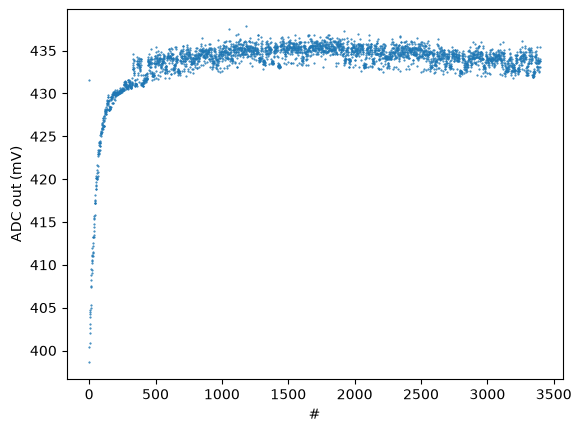

In [7]:
tag2.reflect_wifi(3)
tag2.begin_reading_wifi()
time.sleep(0.2)
voltage_readings_newtag2_wifi=tag2.stop_reading_wifi()
print("Voltage array len:",len(voltage_readings_newtag2_wifi))
plt.plot(voltage_readings_newtag2_wifi, '.', markersize=1)
plt.xlabel("#")
plt.ylabel("ADC out (mV)")

In [ ]:
# tag3.reflect(1)
# tag3.begin_reading()
# time.sleep(10)
# voltage_readings_newtag3=tag3.stop_reading()
# print("Voltage array len:",len(voltage_readings_newtag3), )
# plt.plot(voltage_readings_newtag3, '.', markersize=1)
# plt.xlabel("#")
# plt.ylabel("ADC out (mV)")

In [ ]:
def plotMPPs(t1, t2):
    plt.figure(figsize=(20,10))
    for rep in range(5):
        plt.subplot(2,3,rep+1)
        print("Begin reading")     
        t1.begin_reading()

        print("Starting MPP")     
        mpp_start_time,mpp_stop_time=t2.perform_mpp()

        print("Reading response")
        voltage_readings=t1.stop_reading()
        print(f"Got {len(voltage_readings)} readings.")

        mpp_time_elapsed=mpp_stop_time-mpp_start_time
        plot_all_time=np.arange(0,mpp_time_elapsed,mpp_time_elapsed/len(voltage_readings))
        plot_end_time=plot_all_time[-1]
        ver_lines=[]
        for i in range(6):
            ver_lines.append(plot_end_time-0.005*(i+1))

        for v in ver_lines:
            plt.axvline(x = v, color = 'b', label = 'axvline - full height')

        plt.plot(np.arange(0,mpp_time_elapsed,mpp_time_elapsed/len(voltage_readings))[:len(voltage_readings)],voltage_readings)

        plt.xlabel("Time [s]")
        plt.ylabel("ADC out [mV]")

Begin reading
Starting MPP
Reading response
Begin reading
Starting MPP
Reading response
Begin reading
Starting MPP
Reading response
Begin reading
Starting MPP
Reading response
Begin reading
Starting MPP
Reading response


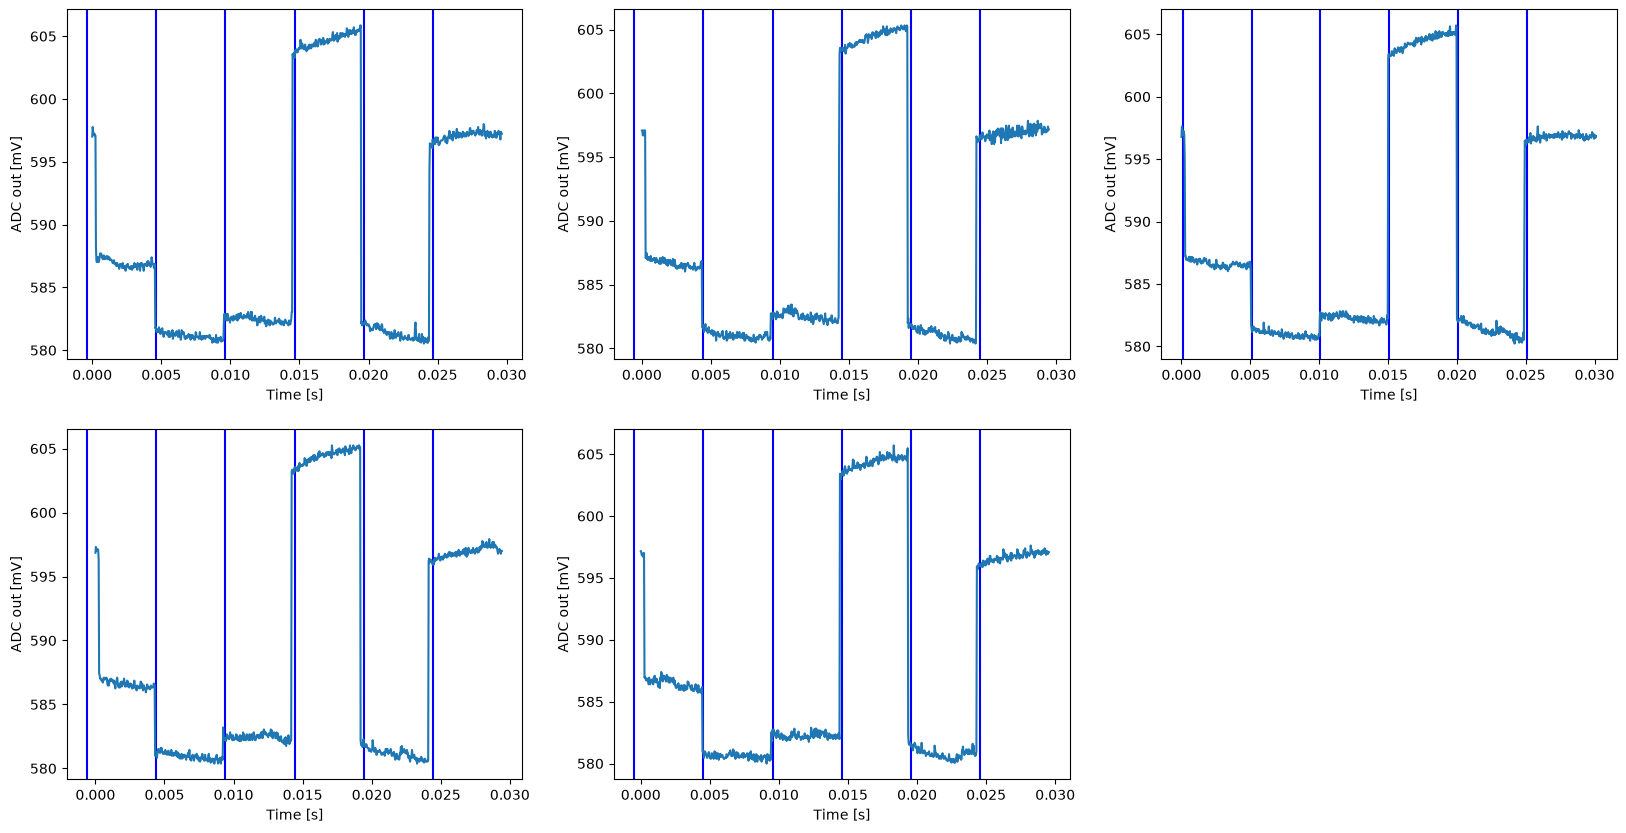

In [41]:
plotMPPs(t1=tag1, t2=tag2)

Begin reading
Starting MPP
Reading response
Begin reading
Starting MPP
Reading response
Begin reading
Starting MPP
Reading response
Begin reading
Starting MPP
Reading response
Begin reading
Starting MPP
Reading response


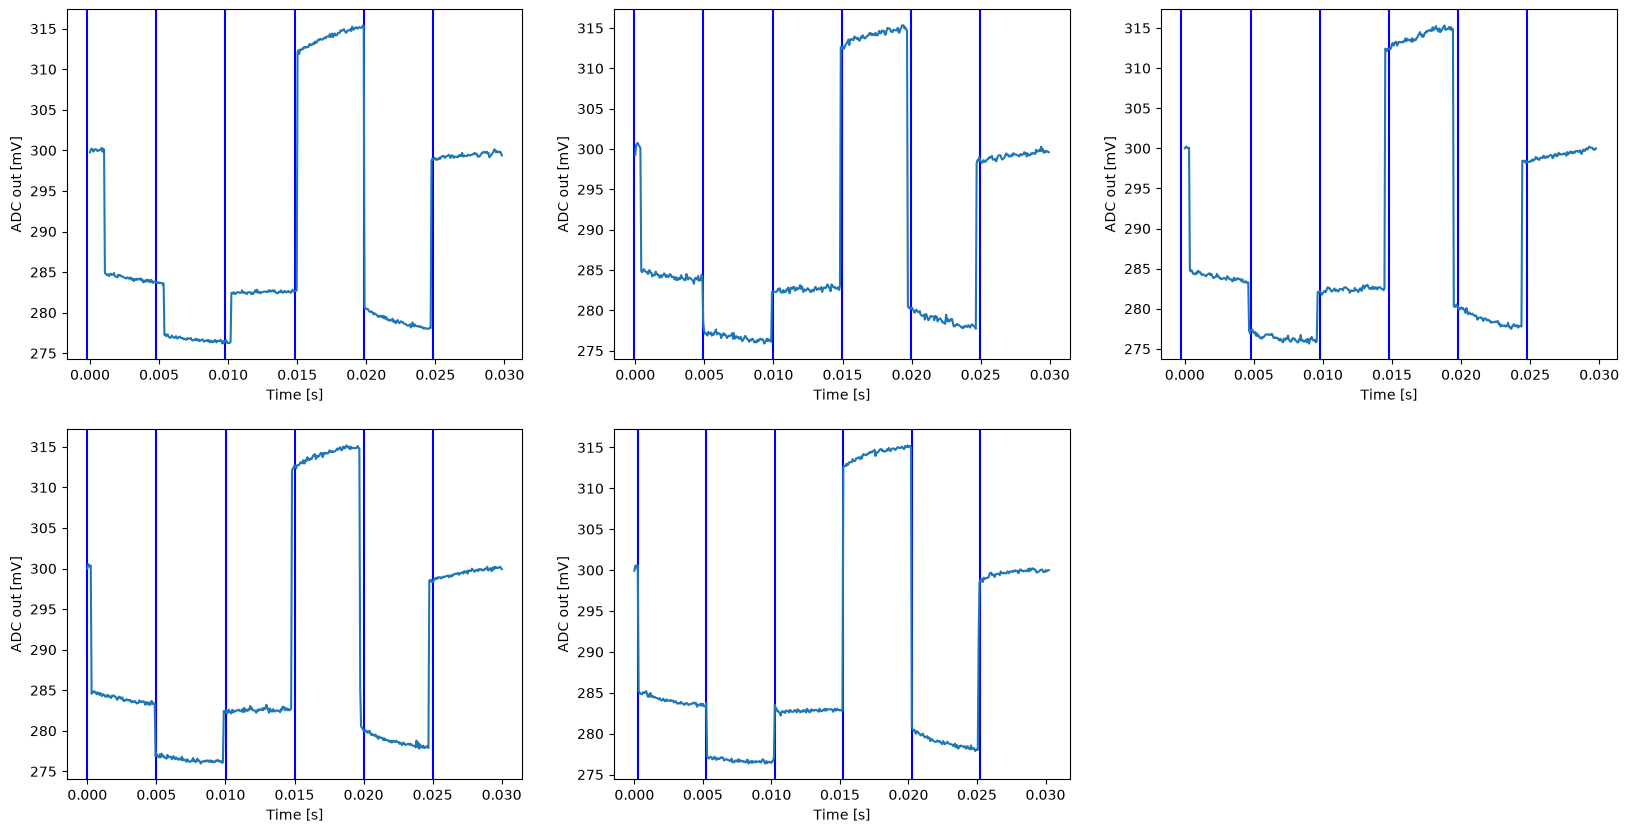

In [43]:
plotMPPs(t1=tag2, t2=tag1)


In [ ]:
len